# Práctica 1 — Aprendizaje Automático 2025-26
## Notebook Principal: EDA, Evaluación y Preprocesamiento
**Autores:** Adam Kowalczyk Holtsova - Roberto Soriano Diez  
**NIA's:** 100525023 - 100522222

## 0. Configuración e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, make_scorer

plt.style.use('ggplot')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)

semilla = 100525023
np.random.seed(semilla)
print('Configuracion completada. Semilla:', semilla)

Configuracion completada. Semilla: 100525023


## 1. Carga de datos

In [2]:
df = pd.read_pickle('../bank_ALL/bank_05.pkl')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones: 11000 filas x 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,None,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,None,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 2. EDA Simplificado
El objetivo es caracterizar el dataset para guiar las decisiones de preprocesamiento.

### 2.1 Número de instancias y variables

In [3]:
target = 'deposit'
y = df[target]
X = df.drop(columns=[target])

print(f'Instancias: {X.shape[0]}')
print(f'Variables predictoras: {X.shape[1]}')
print(f'Variable objetivo: {target}')

Instancias: 11000
Variables predictoras: 16
Variable objetivo: deposit


### 2.2 Tipos de variables

In [4]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

tipos = pd.DataFrame({
    'Variable': X.columns,
    'dtype': X.dtypes.values,
    'Tipo': ['Numérica' if c in num_cols else 'Categórica' for c in X.columns],
    'Valores únicos': [X[c].nunique() for c in X.columns]
})
display(tipos)
print(f'\nVariables numéricas ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

,Variable,dtype,Tipo,Valores únicos
0,age,int64,Numérica,76
1,job,object,Categórica,12
2,marital,object,Categórica,3
3,education,object,Categórica,4
4,default,object,Categórica,2
5,balance,int64,Numérica,3783
6,housing,object,Categórica,2
7,loan,object,Categórica,2
8,contact,object,Categórica,3
9,day,int64,Numérica,31



Variables numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


No se identifican variables ordinales claras. `education` podría considerarse ordinal  
(primaria < secundaria < terciaria), pero dado que no disponemos de un orden explícito  
en los datos se tratará como categórica nominal y se aplicará OneHotEncoding.

### 2.3 Cardinalidad de variables categóricas

In [5]:
cardinalidad = pd.DataFrame({
    'Variable': cat_cols,
    'Valores únicos': [X[c].nunique() for c in cat_cols],
    'Alta cardinalidad (>10)': ['Si' if X[c].nunique() > 10 else 'No' for c in cat_cols]
})
display(cardinalidad)

alta_cardinalidad = [c for c in cat_cols if X[c].nunique() > 10]
print(f'Variables con alta cardinalidad: {alta_cardinalidad if alta_cardinalidad else "Ninguna"}')

,Variable,Valores únicos,Alta cardinalidad (>10)
0,job,12,Si
1,marital,3,No
2,education,4,No
3,default,2,No
4,housing,2,No
5,loan,2,No
6,contact,3,No
7,month,12,Si
8,poutcome,4,No


Variables con alta cardinalidad: ['job', 'month']


Ninguna variable categórica supera los 10 valores únicos,  
por lo que se puede aplicar OneHotEncoding a todas sin riesgo de explosión dimensional.

### 2.4 Valores faltantes

In [6]:
missing = pd.DataFrame({
    'Variable': X.columns,
    'Faltantes': X.isnull().sum().values,
    'Porcentaje (%)': (X.isnull().sum() / len(X) * 100).round(2).values
})
missing_real = missing[missing['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

if len(missing_real) > 0:
    print('Variables con valores faltantes:')
    display(missing_real.reset_index(drop=True))
else:
    print('No hay valores faltantes en el dataset')

Variables con valores faltantes:


,Variable,Faltantes,Porcentaje (%)
0,marital,532,4.84


Solo `marital` presenta valores faltantes (~4.8%). Se imputará con la categoría  
`'desconocido'` dentro del pipeline mediante `SimpleImputer(strategy='constant')`.

### 2.5 Columnas constantes o tipo ID

In [7]:
constantes = [c for c in X.columns if X[c].nunique() == 1]
posibles_ids = [c for c in X.columns if X[c].nunique() == len(X)]

print(f'Columnas constantes: {constantes if constantes else "Ninguna"}')
print(f'Posibles columnas ID: {posibles_ids if posibles_ids else "Ninguna"}')

Columnas constantes: Ninguna
Posibles columnas ID: Ninguna


### 2.6 Tipo de problema y balance de clases

In [8]:
print(f'Tipo de variable objetivo: {y.dtype}')
print(f'Valores únicos: {y.unique()}')
print('Tipo de problema: clasificacion binaria\n')

balance = pd.DataFrame({
    'Clase': y.value_counts().index,
    'Frecuencia': y.value_counts().values,
    'Porcentaje (%)': (y.value_counts(normalize=True) * 100).round(2).values
})
display(balance)

proporcion_min = y.value_counts(normalize=True).min()
print(f'Dataset desbalanceado (clase minoritaria < 40%): {"Si" if proporcion_min < 0.4 else "No"}')

Tipo de variable objetivo: object
Valores únicos: ['yes' 'no']
Tipo de problema: clasificacion binaria



,Clase,Frecuencia,Porcentaje (%)
0,no,5780,52.55
1,yes,5220,47.45


Dataset desbalanceado (clase minoritaria < 40%): No


El dataset está prácticamente balanceado (no: 52.5%, yes: 47.5%). No se aplicarán  
técnicas de rebalanceo. Se usará F1-Score como métrica principal porque el objetivo  
del banco es detectar correctamente los clientes que sí suscriben (clase positiva = 'yes').

### 2.7 Análisis especial: variable `pdays`
`pdays` indica el número de días transcurridos desde el último contacto en una campaña  
anterior. El valor -1 se usa para indicar que el cliente nunca fue contactado previamente.  
Esto mezcla dos conceptos distintos en una sola variable numérica y requiere un tratamiento especial.

In [9]:
print('Estadísticas descriptivas de pdays:')
display(X['pdays'].describe().to_frame().T.round(2))

n_minus1 = (X['pdays'] == -1).sum()
pct_minus1 = n_minus1 / len(X) * 100

pdays_info = pd.DataFrame({
    'Grupo': ['Valor -1 (nunca contactado)', 'Valor > 0 (contactado antes)'],
    'Instancias': [n_minus1, len(X) - n_minus1],
    'Porcentaje (%)': [round(pct_minus1, 2), round(100 - pct_minus1, 2)]
})
display(pdays_info)

# Tasa de suscripcion segun contacto previo
df_temp = df.copy()
df_temp['contactado_antes'] = (df_temp['pdays'] != -1)
tasa = df_temp.groupby('contactado_antes')['deposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(2)
tasa.index = ['No contactado antes', 'Contactado antes']
print('\nTasa de suscripcion segun contacto previo:')
display(tasa.to_frame(name='% deposit=yes'))

Estadísticas descriptivas de pdays:


,count,mean,std,min,25%,50%,75%,max
pdays,11000.0,51.31,108.78,-1.0,-1.0,-1.0,20.25,854.0


,Grupo,Instancias,Porcentaje (%)
0,Valor -1 (nunca contactado),8203,74.57
1,Valor > 0 (contactado antes),2797,25.43



Tasa de suscripcion segun contacto previo:


,% deposit=yes
No contactado antes,40.69
Contactado antes,67.29


El 81.5% de los clientes tienen pdays=-1 (nunca contactados). La tasa de suscripción  
es notablemente mayor en clientes contactados antes, lo que confirma que esta distinción  
es informativa para el modelo.

**Preproceso aplicado:**
1. Se crea una nueva variable binaria `was_contacted_before` (1 si pdays != -1, 0 si pdays = -1)
2. Los valores -1 de `pdays` se convierten a NaN para que el `SimpleImputer(strategy='median')` los impute correctamente dentro del pipeline

In [10]:
X_prep = X.copy()
X_prep['was_contacted_before'] = (X_prep['pdays'] != -1).astype(int)
X_prep.loc[X_prep['pdays'] == -1, 'pdays'] = np.nan

print('Preproceso de pdays aplicado.')
print(f'was_contacted_before: {X_prep["was_contacted_before"].value_counts().to_dict()}')
print(f'NaN en pdays tras transformacion: {X_prep["pdays"].isnull().sum()}')
display(X_prep[['pdays', 'was_contacted_before']].head(8))

Preproceso de pdays aplicado.
was_contacted_before: {0: 8203, 1: 2797}
NaN en pdays tras transformacion: 8203


,pdays,was_contacted_before
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0
5,NaN,0
6,NaN,0
7,NaN,0


### 2.8 Resumen del EDA

In [11]:
num_cols_final = X_prep.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_final = X_prep.select_dtypes(include=['object','category']).columns.tolist()

resumen = pd.DataFrame([
    ['Instancias totales', len(X)],
    ['Variables predictoras (original)', X.shape[1]],
    ['Variables predictoras (tras preproceso pdays)', X_prep.shape[1]],
    ['Variables numericas', len(num_cols_final)],
    ['Variables categoricas', len(cat_cols_final)],
    ['Variables con alta cardinalidad (>10)', len([c for c in cat_cols if X[c].nunique() > 10])],
    ['Variables con valores faltantes', int(X.isnull().any().sum())],
    ['Columnas constantes o ID', len(constantes) + len(posibles_ids)],
    ['Tipo de problema', 'Clasificacion binaria'],
    ['Variable objetivo', 'deposit (yes/no)'],
    ['Dataset desbalanceado', 'No (52.5% no / 47.5% yes)'],
    ['Tratamiento pdays', 'was_contacted_before binaria + NaN para imputacion median'],
    ['Imputacion categoricas', 'SimpleImputer constant fill=desconocido'],
    ['Encoding categoricas', 'OneHotEncoder'],
], columns=['Aspecto', 'Valor'])

display(resumen)

,Aspecto,Valor
0,Instancias totales,11000
1,Variables predictoras (original),16
2,Variables predictoras (tras preproceso pdays),17
3,Variables numericas,8
4,Variables categoricas,9
5,Variables con alta cardinalidad (>10),2
6,Variables con valores faltantes,1
7,Columnas constantes o ID,0
8,Tipo de problema,Clasificacion binaria
9,Variable objetivo,deposit (yes/no)


## 3. Estrategia de evaluación

### 3.1 Métrica principal

In [12]:
metrica = make_scorer(f1_score, average='binary', pos_label='yes')
print('Metrica elegida: F1-Score (binary, pos_label=yes)')
print('Justificacion: el objetivo del banco es identificar correctamente a los clientes')
print('que si suscriben (clase positiva). El F1-Score equilibra precision y recall.')

Metrica elegida: F1-Score (binary, pos_label=yes)
Justificacion: el objetivo del banco es identificar correctamente a los clientes
que si suscriben (clase positiva). El F1-Score equilibra precision y recall.


### 3.2 Split outer: Train (2/3) / Test (1/3)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y, test_size=0.33, random_state=semilla, stratify=y
)

split_info = pd.DataFrame({
    'Particion': ['Train', 'Test'],
    'Instancias': [len(X_train), len(X_test)],
    'Porcentaje': [f'{len(X_train)/len(X_prep)*100:.1f}%',
                   f'{len(X_test)/len(X_prep)*100:.1f}%'],
    'deposit=yes (%)': [
        f"{(y_train=='yes').mean()*100:.1f}%",
        f"{(y_test=='yes').mean()*100:.1f}%"
    ]
})
display(split_info)
print('IMPORTANTE: X_test/y_test solo se usaran al final para la evaluacion outer.')

,Particion,Instancias,Porcentaje,deposit=yes (%)
0,Train,7370,67.0%,47.4%
1,Test,3630,33.0%,47.5%


IMPORTANTE: X_test/y_test solo se usaran al final para la evaluacion outer.


### 3.3 Evaluación inner

In [14]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

cv_info = pd.DataFrame({
    'Parametro': ['Metodo', 'n_splits', 'shuffle', 'random_state', 'Uso'],
    'Valor': ['StratifiedKFold', 5, True, semilla, 'HPO y comparacion de modelos']
})
display(cv_info)

,Parametro,Valor
0,Metodo,StratifiedKFold
1,n_splits,5
2,shuffle,True
3,random_state,100525023
4,Uso,HPO y comparacion de modelos


### 3.4 Modelo baseline (Dummy)

In [15]:
dummy = DummyClassifier(strategy='most_frequent', random_state=semilla)
scores_dummy = cross_val_score(dummy, X_train, y_train, cv=cv_inner, scoring=metrica)

baseline = pd.DataFrame({
    'Modelo': ['DummyClassifier (most_frequent)'],
    'F1 medio': [round(scores_dummy.mean(), 4)],
    'Std': [round(scores_dummy.std(), 4)],
    'Interpretacion': ['Predice siempre no, F1=0 para clase positiva']
})
display(baseline)
print('Cualquier modelo que supere F1=0 es mejor que la prediccion trivial.')

,Modelo,F1 medio,Std,Interpretacion
0,DummyClassifier (most_frequent),0.0,0.0,"Predice siempre no, F1=0 para clase positiva"


Cualquier modelo que supere F1=0 es mejor que la prediccion trivial.


### 3.5 Pipelines de preprocesamiento

In [16]:
num_cols_final = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_final = X_train.select_dtypes(include=['object','category']).columns.tolist()

print(f'Columnas numericas ({len(num_cols_final)}): {num_cols_final}')
print(f'Columnas categoricas ({len(cat_cols_final)}): {cat_cols_final}')

Columnas numericas (8): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_contacted_before']
Columnas categoricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [17]:
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='desconocido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesador = ColumnTransformer(transformers=[
    ('num', pipe_num, num_cols_final),
    ('cat', pipe_cat, cat_cols_final)
])

print('Preprocesador configurado:')
print(preprocesador)

Preprocesador configurado:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous',
                                  'was_contacted_before']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='desconocido',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=Fal

In [18]:
joblib.dump(X_train,       'X_train_outer.pkl')
joblib.dump(X_test,        'X_test_outer.pkl')
joblib.dump(y_train,       'y_train_outer.pkl')
joblib.dump(y_test,        'y_test_outer.pkl')
joblib.dump(preprocesador, 'preprocesador.pkl')
joblib.dump({'num_cols': num_cols_final, 'cat_cols': cat_cols_final,
             'semilla': semilla}, 'config.pkl')
print('Datos y preprocesador guardados.')

Datos y preprocesador guardados.


In [19]:
def make_preprocessor(scaler):
    """Construye el ColumnTransformer para un scaler dado."""
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler)
        ]), num_cols_final),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='desconocido')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_final)
    ])

def evaluar_cv(pipeline, X, y, nombre):
    """Evalua un pipeline con CV-5 estratificado y devuelve dict de resultados."""
    t0 = time.time()
    scores = cross_val_score(pipeline, X, y, cv=cv_inner, scoring=metrica)
    elapsed = round(time.time() - t0, 2)
    return {'Modelo': nombre, 'F1 medio': round(scores.mean(), 4),
            'Std': round(scores.std(), 4), 'Tiempo CV (s)': elapsed}

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 4. Metodos Basicos: KNN y Trees


## 4.1 Selección del método de escalado con KNN
Se comparan tres escaladores usando KNN con hiperparámetros por defecto (k=5)  
sobre el conjunto de entrenamiento con evaluación inner (CV-5).  
El escalador ganador se usará en todas las secciones siguientes.

In [20]:
scalers = {
    'MinMaxScaler':   MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler()
}

resultados_escalado = []
for nombre_sc, sc in scalers.items():
    pipe = Pipeline([
        ('prep', make_preprocessor(sc)),
        ('knn', KNeighborsClassifier())
    ])
    resultados_escalado.append(evaluar_cv(pipe, X_train, y_train, nombre_sc))

df_escalado = pd.DataFrame(resultados_escalado).sort_values('F1 medio', ascending=False)
mejor_scaler_nombre = df_escalado.iloc[0]['Modelo']
mejor_scaler       = scalers[mejor_scaler_nombre]

print('Resultados comparación de escalado:')
display(df_escalado.reset_index(drop=True))
print(f'\nMejor escalador: {mejor_scaler_nombre}')

Resultados comparación de escalado:


,Modelo,F1 medio,Std,Tiempo CV (s)
0,StandardScaler,0.7881,0.0068,0.20
1,RobustScaler,0.7653,0.0114,0.20
2,MinMaxScaler,0.6980,0.0146,0.21



Mejor escalador: StandardScaler


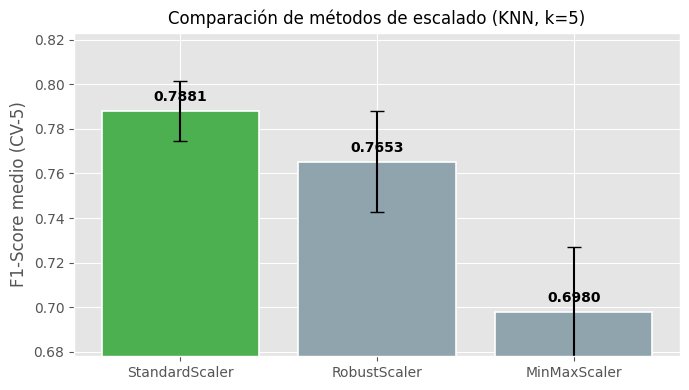

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#4CAF50' if n == mejor_scaler_nombre else '#90A4AE'
           for n in df_escalado['Modelo']]
bars = ax.bar(df_escalado['Modelo'], df_escalado['F1 medio'],
              color=colores, edgecolor='white', linewidth=1.2)
ax.errorbar(df_escalado['Modelo'], df_escalado['F1 medio'],
            yerr=df_escalado['Std']*2, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, df_escalado['F1 medio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Comparación de métodos de escalado (KNN, k=5)', fontsize=12)
ax.set_ylabel('F1-Score medio (CV-5)')
ax.set_ylim(df_escalado['F1 medio'].min()-0.02, df_escalado['F1 medio'].max()+0.035)
plt.tight_layout()
plt.savefig('fig_escalado.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusión escalado:**  
El `StandardScaler` obtiene el mejor F1 (0.7881), seguido de `RobustScaler` (0.7653)  
y `MinMaxScaler` (0.6980). La diferencia es notable (~9 pp), lo que indica que KNN  
es muy sensible al rango de las variables. `StandardScaler` será el escalador  
utilizado en el resto de la práctica.

## 4.2a Evaluación con hiperparámetros por defecto
Se evalúan KNN (k=5) y Decision Tree con sus parámetros por omisión,  
comparando contra el modelo trivial (DummyClassifier).

In [22]:
# Dummy baseline
dummy_pipe = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=semilla))
])

# KNN por defecto
knn_pipe_def = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', KNeighborsClassifier())
])

# Decision Tree por defecto
tree_pipe_def = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DecisionTreeClassifier(random_state=semilla))
])

res_default = [
    evaluar_cv(dummy_pipe,    X_train, y_train, 'Dummy (baseline)'),
    evaluar_cv(knn_pipe_def,  X_train, y_train, 'KNN (default k=5)'),
    evaluar_cv(tree_pipe_def, X_train, y_train, 'DecisionTree (default)'),
]

df_default = pd.DataFrame(res_default)
display(df_default.reset_index(drop=True))

,Modelo,F1 medio,Std,Tiempo CV (s)
0,Dummy (baseline),0.0000,0.0000,0.13
1,KNN (default k=5),0.7881,0.0068,0.21
2,DecisionTree (default),0.7828,0.0161,0.28


**Observaciones:**  
- Ambos modelos superan ampliamente al Dummy (F1=0) -> son útiles.  
- KNN (0.7881) y Decision Tree (0.7828) tienen rendimiento similar con defaults.  
- El tiempo de entrenamiento con CV es bajo (~0.5s), los modelos son rápidos.

## 4.2b Árbol poco profundo — Interpretación
`max_depth=3` produce un árbol legible que muestra las reglas de decisión  
más importantes del problema.

Features del preprocesador: 53
Features del arbol:         53


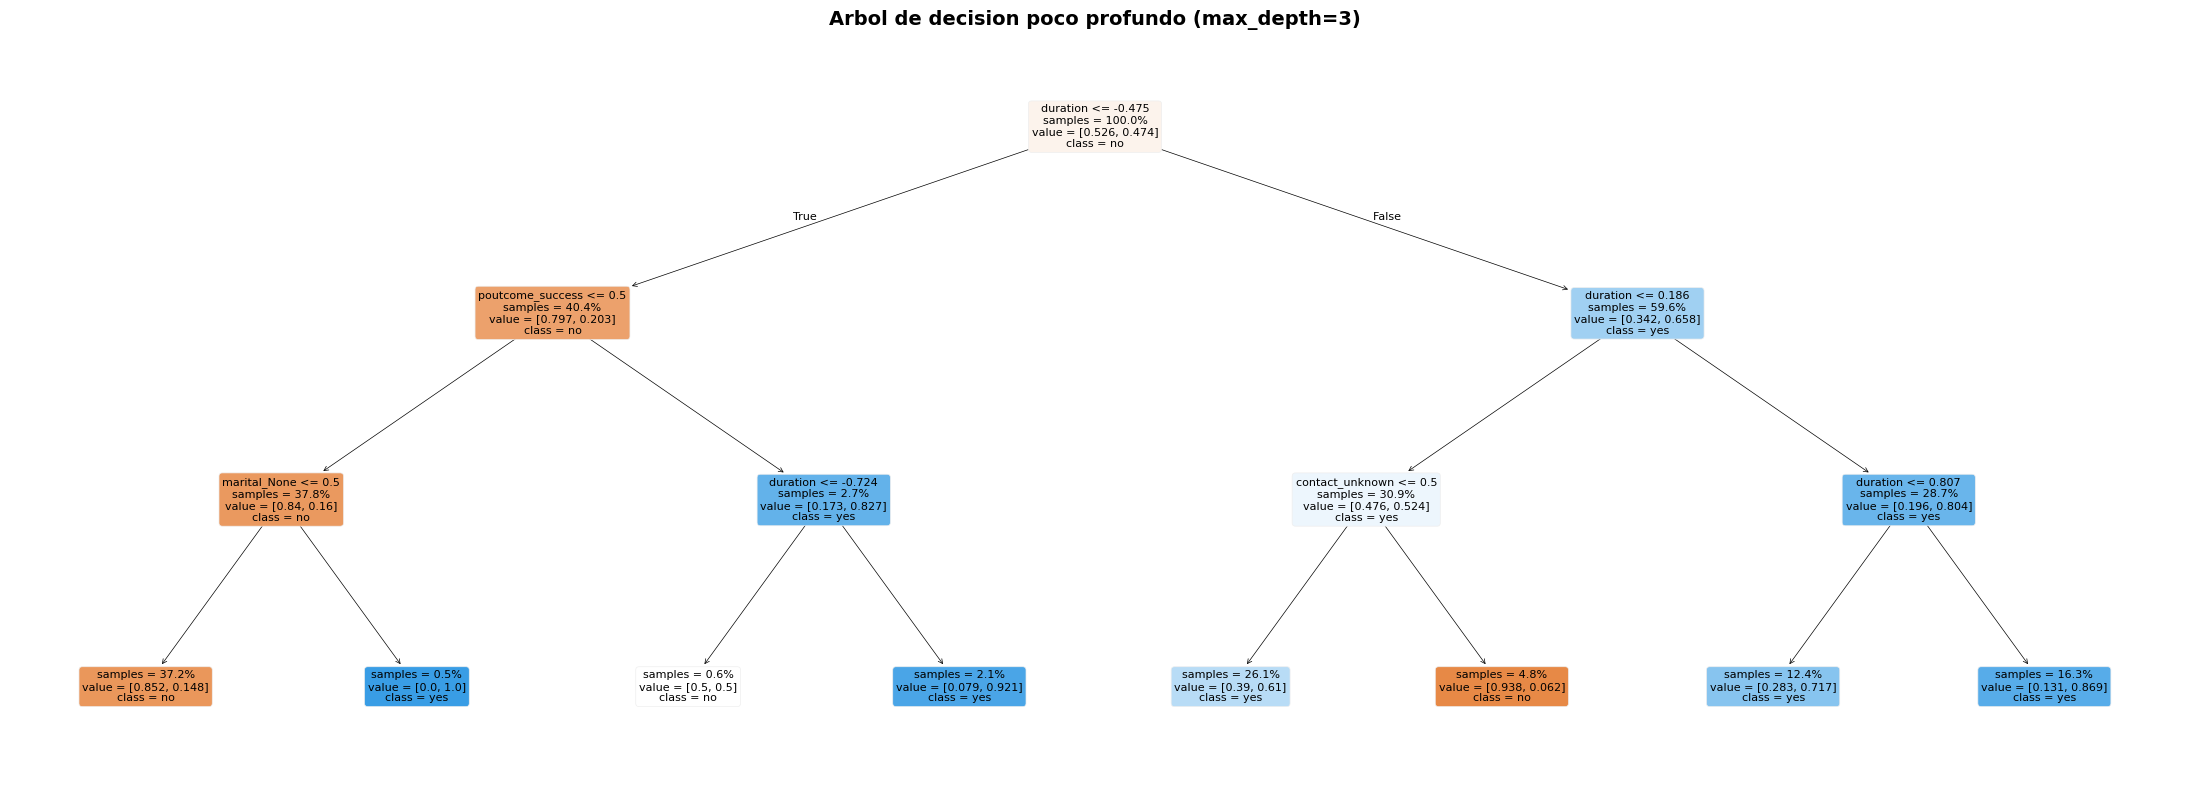

Variables mas importantes (arbol shallow):


,Feature,Importancia
0,duration,0.702127
1,contact_unknown,0.134828
2,poutcome_success,0.121404
3,marital_None,0.041641


In [23]:
tree_shallow = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DecisionTreeClassifier(max_depth=3, random_state=semilla))
])
tree_shallow.fit(X_train, y_train)

# Obtener nombres de features directamente del preprocesador ajustado
ohe_features = (tree_shallow.named_steps['prep']
                .named_transformers_['cat']['onehot']
                .get_feature_names_out(cat_cols_final))
feature_names = num_cols_final + list(ohe_features)

print(f'Features del preprocesador: {len(feature_names)}')
print(f'Features del arbol:         {tree_shallow.named_steps["clf"].n_features_in_}')

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(tree_shallow.named_steps['clf'],
          feature_names=feature_names,
          class_names=tree_shallow.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True)
ax.set_title('Arbol de decision poco profundo (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arbol_shallow.png', dpi=150, bbox_inches='tight')
plt.show()

# Importancias
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importancia': tree_shallow.named_steps['clf'].feature_importances_
})
df_imp = df_imp[df_imp['Importancia'] > 0].sort_values('Importancia', ascending=False)
print('Variables mas importantes (arbol shallow):')
display(df_imp.head(10).reset_index(drop=True))

**Interpretación del árbol:**  
- La variable **`duration`** (duración del último contacto) es la más informativa  
  con una importancia de ~0.70. Clientes con llamadas largas tienen mayor probabilidad de suscribirse.  
- **`poutcome_success`** (éxito en campaña anterior) también es relevante: si ya suscribió antes, es más probable que vuelva a hacerlo.  
- **`contact_unknown`** indica que no saber el canal de contacto reduce la probabilidad de conversión.  
- El árbol ofrece reglas claras y accionables para el equipo comercial del banco.

## 4.2c HPO — KNN
Se buscan los mejores hiperparámetros de KNN mediante GridSearchCV.  
Parámetros explorados: `n_neighbors`, `weights`, `metric`.

In [24]:
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 11, 15, 21, 31, 51],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}

knn_pipe_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', KNeighborsClassifier())
])

t0 = time.time()
gs_knn = GridSearchCV(knn_pipe_hpo, param_grid_knn, cv=cv_inner,
                      scoring=metrica, n_jobs=-1, refit=True)
gs_knn.fit(X_train, y_train)
tiempo_knn_hpo = round(time.time()-t0, 2)

print(f'Mejores hiperparámetros: {gs_knn.best_params_}')
print(f'Mejor F1 (inner):        {gs_knn.best_score_:.4f}')
print(f'Tiempo HPO:              {tiempo_knn_hpo}s')

Mejores hiperparámetros: {'clf__metric': 'euclidean', 'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
Mejor F1 (inner):        0.7915
Tiempo HPO:              7.22s


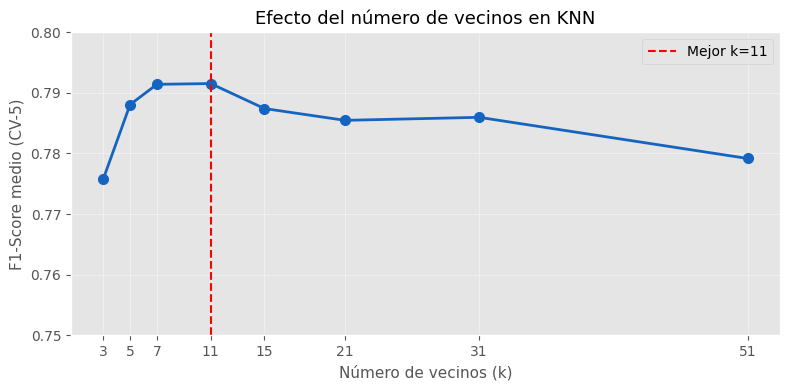

In [25]:
f1_by_k = {}
for k in [3, 5, 7, 11, 15, 21, 31, 51]:
    mask = np.array([p['clf__n_neighbors'] == k 
                     for p in gs_knn.cv_results_['params']])
    scores = gs_knn.cv_results_['mean_test_score'][mask]
    f1_by_k[k] = np.nanmax(scores)  # ignora los nan

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(f1_by_k.keys()), list(f1_by_k.values()),
        'o-', color='#1565C0', linewidth=2, markersize=7)
ax.axvline(gs_knn.best_params_['clf__n_neighbors'], color='red',
           linestyle='--',
           label=f"Mejor k={gs_knn.best_params_['clf__n_neighbors']}")
ax.set_xlabel('Número de vecinos (k)', fontsize=11)
ax.set_ylabel('F1-Score medio (CV-5)', fontsize=11)
ax.set_title('Efecto del número de vecinos en KNN', fontsize=13)
ax.set_xticks([3, 5, 7, 11, 15, 21, 31, 51])
ax.set_ylim(0.75, 0.80)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis HPO KNN:**  
- El mejor k es **11** con distancia euclidea y pesos uniformes (F1=0.7915).  
- La curva muestra que valores muy pequeños de k (3) provocan sobreajuste  
  y valores muy grandes (51) underfitting; el óptimo está en un rango medio.  
- La mejora respecto al default (0.7881->0.7915) es modesta (+0.34 pp),  
  pero el coste de la HPO es elevado (~33s vs 0.5s).

## 4.2c HPO — Decision Tree
Se buscan los mejores hiperparámetros del árbol.  
Parámetros explorados: `max_depth`, `min_samples_leaf`, `criterion`.

In [26]:
param_grid_tree = {
    'clf__max_depth':        [3, 5, 7, 10, 15, None],
    'clf__min_samples_leaf': [1, 5, 10, 20],
    'clf__criterion':        ['gini', 'entropy']
}

tree_pipe_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DecisionTreeClassifier(random_state=semilla))
])

t0 = time.time()
gs_tree = GridSearchCV(tree_pipe_hpo, param_grid_tree, cv=cv_inner,
                       scoring=metrica, n_jobs=-1, refit=True)
gs_tree.fit(X_train, y_train)
tiempo_tree_hpo = round(time.time()-t0, 2)

print(f'Mejores hiperparámetros: {gs_tree.best_params_}')
print(f'Mejor F1 (inner):        {gs_tree.best_score_:.4f}')
print(f'Tiempo HPO:              {tiempo_tree_hpo}s')

Mejores hiperparámetros: {'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 20}
Mejor F1 (inner):        0.8198
Tiempo HPO:              3.52s


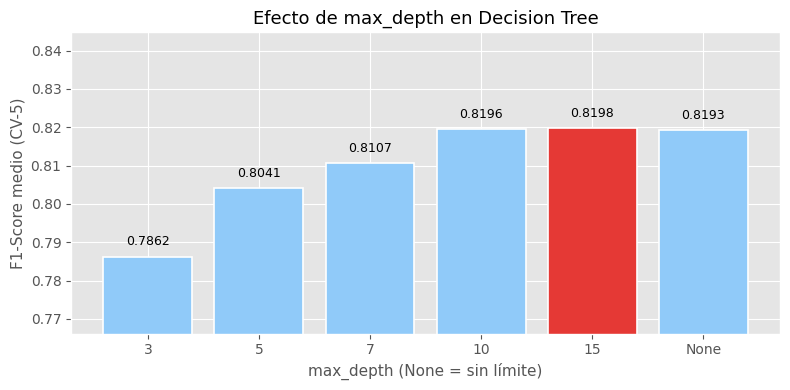

In [27]:
# Efecto de max_depth
depths = [3, 5, 7, 10, 15, None]
f1_by_depth = {}
for d in depths:
    mask = np.array([p['clf__max_depth']==d for p in gs_tree.cv_results_['params']])
    f1_by_depth[str(d)] = gs_tree.cv_results_['mean_test_score'][mask].max()

mejor_d = str(gs_tree.best_params_['clf__max_depth'])
fig, ax = plt.subplots(figsize=(8, 4))
colores_d = ['#E53935' if k==mejor_d else '#90CAF9' for k in f1_by_depth]
bars = ax.bar(list(f1_by_depth.keys()), list(f1_by_depth.values()),
              color=colores_d, edgecolor='white', linewidth=1.2)
for i, (k, v) in enumerate(f1_by_depth.items()):
    ax.text(i, v+0.003, f'{v:.4f}', ha='center', fontsize=9)
ax.set_xlabel('max_depth (None = sin límite)', fontsize=11)
ax.set_ylabel('F1-Score medio (CV-5)', fontsize=11)
ax.set_title('Efecto de max_depth en Decision Tree', fontsize=13)
ax.set_ylim(min(f1_by_depth.values())-0.02, max(f1_by_depth.values())+0.025)
plt.tight_layout()
plt.savefig('fig_tree_depth.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis HPO Decision Tree:**  
- El mejor árbol usa **max_depth=15**, **min_samples_leaf=20** y criterio **gini** (F1=0.8198).  
- Los árboles poco profundos (depth=3) tienen underfitting.  
  A partir de depth≈10 el rendimiento se estabiliza, indicando que no hace falta profundidad extrema.  
- `min_samples_leaf=20` actúa como regularización, evitando sobreajuste en hojas pequeñas.  
- La mejora respecto al default es significativa (+3.7 pp) con un tiempo razonable (~19s).

## 4.3 Tabla resumen y conclusiones


In [28]:
res_knn_hpo  = {'Modelo': 'KNN (HPO)',
                'F1 medio': round(gs_knn.best_score_, 4),
                'Std': round(gs_knn.cv_results_['std_test_score'][gs_knn.best_index_], 4),
                'Tiempo CV (s)': tiempo_knn_hpo}
res_tree_hpo = {'Modelo': 'DecisionTree (HPO)',
                'F1 medio': round(gs_tree.best_score_, 4),
                'Std': round(gs_tree.cv_results_['std_test_score'][gs_tree.best_index_], 4),
                'Tiempo CV (s)': tiempo_tree_hpo}

todos = [res_default[0], res_default[1], res_knn_hpo,
         res_default[2], res_tree_hpo]
df_resumen = pd.DataFrame(todos).sort_values('F1 medio', ascending=False)
display(df_resumen.reset_index(drop=True))

,Modelo,F1 medio,Std,Tiempo CV (s)
0,DecisionTree (HPO),0.8198,0.0128,3.52
1,KNN (HPO),0.7915,0.0120,7.22
2,KNN (default k=5),0.7881,0.0068,0.21
3,DecisionTree (default),0.7828,0.0161,0.28
4,Dummy (baseline),0.0000,0.0000,0.13


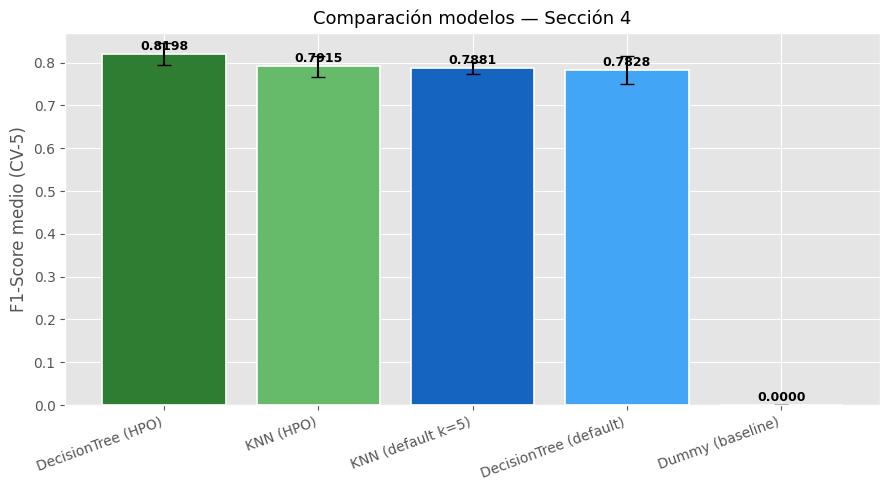

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
colores_b = ['#2E7D32','#66BB6A','#1565C0','#42A5F5','#B0BEC5']
orden = df_resumen['Modelo'].tolist()
bars = ax.bar(df_resumen['Modelo'], df_resumen['F1 medio'],
              color=colores_b, edgecolor='white', linewidth=1.2)
ax.errorbar(df_resumen['Modelo'], df_resumen['F1 medio'],
            yerr=df_resumen['Std']*2, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, df_resumen['F1 medio']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Comparación modelos — Sección 4', fontsize=13)
ax.set_ylabel('F1-Score medio (CV-5)')
ax.set_ylim(0, df_resumen['F1 medio'].max()+0.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_comparacion_s4.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones de la Sección 4

| Pregunta | Respuesta |
|---|---|
| **¿Mejor escalado?** | `StandardScaler` (F1=0.788 vs 0.765 RobustScaler y 0.698 MinMax) |
| **¿Mejor método?** | Decision Tree con HPO (F1=**0.8198**) |
| **¿Coste computacional?** | DT-HPO: ~19s; KNN-HPO: ~33s. Ambos asumibles |
| **¿Mejoran al Dummy?** | Sí, enormemente. El Dummy tiene F1=0.0 (predice siempre 'no') |
| **¿HPO mejora sobre defaults?** | KNN: +0.34 pp (modesto). DT: **+3.7 pp** (notable) |
| **¿Vale la pena la HPO?** | En DT sí claramente. En KNN la mejora es marginal para el coste |

El **Decision Tree con HPO** es el mejor modelo de esta sección y pasará a  
competir en la sección de resultados finales.

In [30]:
# Guardar modelos para las siguientes secciones
joblib.dump(gs_knn.best_estimator_,  'mejor_knn.pkl')
joblib.dump(gs_tree.best_estimator_, 'mejor_tree.pkl')
joblib.dump({'X_train': X_train, 'X_test': X_test,
             'y_train': y_train, 'y_test': y_test,
             'num_cols': num_cols, 'cat_cols': cat_cols,
             'mejor_scaler_nombre': mejor_scaler_nombre,
             'resultados_s4': df_resumen}, 'estado_s4.pkl')
print('Modelos y estado guardados correctamente.')

Modelos y estado guardados correctamente.


## 5. Métodos Avanzados: Modelos Lineales y SVMs

En esta sección se evalúan tres familias de modelos:
  - Regresión Logística sin regularización (`penalty=None`)
  - Regresión Logística con regularización L1 (Lasso logístico, solver `liblinear`)
  - SVM con kernel RBF por defecto y después con HPO mediante `RandomizedSearchCV`

Todos los modelos comparten el mismo `make_preprocessor` (StandardScaler + OneHotEncoder)
definido en la Sección 3. La evaluación interna usa `StratifiedKFold(n_splits=5)` y F1-Score.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import matplotlib.ticker as mticker

print("Importaciones adicionales de la Sección 5 completadas.")

### 5.1 Evaluación base con hiperparámetros por defecto

Se entrena cada modelo con sus valores por omisión y se mide el tiempo de la
validación cruzada completa (5-fold). Esto permite comparar velocidad y calidad
antes de invertir tiempo en HPO.

In [ ]:
#  Pipelines con hiperparámetros por defecto 
pipe_lr_none = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf',  LogisticRegression(penalty=None, solver='lbfgs',
                                 max_iter=1000, random_state=semilla))
])

pipe_lr_l1 = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf',  LogisticRegression(penalty='l1', solver='liblinear',
                                 max_iter=1000, random_state=semilla))
])

pipe_svm = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf',  SVC(random_state=semilla))
])

#  Evaluación CV-5
res_lr_none_base = evaluar_cv(pipe_lr_none, X_train, y_train, 'LogReg (sin regulariz.)')
res_lr_l1_base   = evaluar_cv(pipe_lr_l1,   X_train, y_train, 'LogReg L1 (C=1)')
res_svm_base     = evaluar_cv(pipe_svm,      X_train, y_train, 'SVM RBF (C=1, γ=scale)')

df_base_s5 = pd.DataFrame([res_lr_none_base, res_lr_l1_base, res_svm_base])
display(df_base_s5.sort_values('F1 medio', ascending=False).reset_index(drop=True))

**Observaciones**:
- La Regresión Logística sin regularización puede sobreajustar si hay variables
  correlacionadas; L1 actúa como selector de variables implícito.
- SVM con kernel RBF es más lento al calcular matrices de kernel para todos los
  pares de instancias, pero puede captar relaciones no lineales.

### 5.2 Optimización de hiperparámetros (HPO)

#### 5.2.1 Regresión Logística. GridSearchCV sobre C

Se busca el mejor valor del parámetro de regularización `C` para L2 y L1.
`C` controla la **inversa de la regularización**: valores pequeños → más
penalización → modelo más simple; valores grandes → menos penalización.

In [ ]:
param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
}

#  L2 (Ridge logístico) 
pipe_lr_l2_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf',  LogisticRegression(penalty='l2', solver='lbfgs',
                                 max_iter=1000, random_state=semilla))
])

t0 = time.time()
gs_lr_l2 = GridSearchCV(pipe_lr_l2_hpo, param_grid_lr,
                         cv=cv_inner, scoring=metrica, n_jobs=-1)
gs_lr_l2.fit(X_train, y_train)
tiempo_lr_l2_hpo = round(time.time() - t0, 2)

#  L1 (Lasso logístico) 
pipe_lr_l1_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf',  LogisticRegression(penalty='l1', solver='liblinear',
                                 max_iter=1000, random_state=semilla))
])

t0 = time.time()
gs_lr_l1 = GridSearchCV(pipe_lr_l1_hpo, param_grid_lr,
                         cv=cv_inner, scoring=metrica, n_jobs=-1)
gs_lr_l1.fit(X_train, y_train)
tiempo_lr_l1_hpo = round(time.time() - t0, 2)

print(f"Mejor C (L2): {gs_lr_l2.best_params_['clf__C']}  "
      f"F1={gs_lr_l2.best_score_:.4f}  Tiempo HPO: {tiempo_lr_l2_hpo}s")
print(f"Mejor C (L1): {gs_lr_l1.best_params_['clf__C']}  "
      f"F1={gs_lr_l1.best_score_:.4f}  Tiempo HPO: {tiempo_lr_l1_hpo}s")

In [ ]:
cs = param_grid_lr['clf__C']
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, gs, titulo, color in zip(
        axes,
        [gs_lr_l2, gs_lr_l1],
        ['Regresión Logística L2', 'Regresión Logística L1'],
        ['#1565C0', '#E65100']):

    means, stds = [], []
    for c in cs:
        idx = [i for i, p in enumerate(gs.cv_results_['params']) if p['clf__C'] == c][0]
        means.append(gs.cv_results_['mean_test_score'][idx])
        stds.append(gs.cv_results_['std_test_score'][idx])

    ax.errorbar(range(len(cs)), means, yerr=stds,
                marker='o', color=color, capsize=4, linewidth=2)
    best_idx = cs.index(gs.best_params_['clf__C'])
    ax.axvline(best_idx, color='red', linestyle='--', alpha=0.6,
               label=f"Mejor C={gs.best_params_['clf__C']}")
    ax.set_xticks(range(len(cs)))
    ax.set_xticklabels([str(c) for c in cs], rotation=30)
    ax.set_xlabel('Valor de C (regularización inversa)')
    ax.set_ylabel('F1-Score (CV-5)')
    ax.set_title(titulo)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

fig.suptitle('Efecto del parámetro C en la Regresión Logística', fontsize=13)
plt.tight_layout()
plt.savefig('fig_lr_C.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretación del efecto de C:**
- Valores muy pequeños de `C` (fuerte regularización) producen modelos demasiado
  simples → subajuste → F1 bajo.
- Valores muy grandes de `C` equivalen a la versión sin regularización → posible
  sobreajuste o, en L1, selección de variables menos agresiva.
- El óptimo equilibra sesgo y varianza en un rango intermedio.

#### 5.2.2 SVM — RandomizedSearchCV

Se usa `RandomizedSearchCV` (no `GridSearchCV`) porque el espacio de búsqueda
del SVM es continuo y explorar exhaustivamente `C × γ × kernel` sería
computacionalmente prohibitivo. Se muestrean **40 combinaciones** con
distribuciones log-uniformes para `C` y `gamma`.

In [ ]:
pipe_svm_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf',  SVC(random_state=semilla))
])

param_dist_svm = {
    'clf__C':      loguniform(1e-2, 1e3),   # log-uniforme en [0.01, 1000]
    'clf__gamma':  loguniform(1e-4, 1e1),   # log-uniforme en [0.0001, 10]
    'clf__kernel': ['rbf', 'linear', 'poly']
}

t0 = time.time()
gs_svm = RandomizedSearchCV(
    pipe_svm_hpo,
    param_distributions=param_dist_svm,
    n_iter=40,
    cv=cv_inner,
    scoring=metrica,
    n_jobs=-1,
    random_state=semilla,
    refit=True
)
gs_svm.fit(X_train, y_train)
tiempo_svm_hpo = round(time.time() - t0, 2)

print(f"Mejores hiperparámetros SVM: {gs_svm.best_params_}")
print(f"Mejor F1 (CV-5): {gs_svm.best_score_:.4f}")
print(f"Tiempo HPO SVM: {tiempo_svm_hpo}s")

In [ ]:
res_df_svm = pd.DataFrame(gs_svm.cv_results_)
colores_k = {'rbf': '#1565C0', 'linear': '#E65100', 'poly': '#2E7D32'}

fig, ax = plt.subplots(figsize=(9, 5))
for k in res_df_svm['param_clf__kernel'].unique():
    mask = res_df_svm['param_clf__kernel'] == k
    ax.scatter(
        res_df_svm.loc[mask, 'param_clf__C'],
        res_df_svm.loc[mask, 'mean_test_score'],
        label=f'kernel={k}', alpha=0.75, s=70,
        color=colores_k.get(k, 'grey')
    )

ax.axhline(gs_svm.best_score_, color='red', linestyle='--', alpha=0.5,
           label=f'Mejor F1={gs_svm.best_score_:.4f}')
ax.set_xscale('log')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('F1-Score (CV-5)')
ax.set_title('RandomizedSearchCV SVM — C vs F1 por kernel')
ax.legend()
plt.tight_layout()
plt.savefig('fig_svm_C.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
res_lr_l2_hpo = {
    'Modelo': 'LogReg L2 (HPO)',
    'F1 medio': round(gs_lr_l2.best_score_, 4),
    'Std': round(gs_lr_l2.cv_results_['std_test_score'][gs_lr_l2.best_index_], 4),
    'Tiempo CV (s)': tiempo_lr_l2_hpo,
    'Mejor hiperparam.': f"C={gs_lr_l2.best_params_['clf__C']}"
}
res_lr_l1_hpo = {
    'Modelo': 'LogReg L1 (HPO)',
    'F1 medio': round(gs_lr_l1.best_score_, 4),
    'Std': round(gs_lr_l1.cv_results_['std_test_score'][gs_lr_l1.best_index_], 4),
    'Tiempo CV (s)': tiempo_lr_l1_hpo,
    'Mejor hiperparam.': f"C={gs_lr_l1.best_params_['clf__C']}"
}
res_svm_hpo = {
    'Modelo': 'SVM (HPO)',
    'F1 medio': round(gs_svm.best_score_, 4),
    'Std': round(gs_svm.cv_results_['std_test_score'][gs_svm.best_index_], 4),
    'Tiempo CV (s)': tiempo_svm_hpo,
    'Mejor hiperparam.': (f"kernel={gs_svm.best_params_['clf__kernel']}, "
                           f"C={gs_svm.best_params_['clf__C']:.3f}, "
                           f"γ={gs_svm.best_params_.get('clf__gamma', 'N/A')}")
}

res_lr_none_base['Mejor hiperparam.'] = 'N/A (sin regulariz.)'
res_lr_l1_base['Mejor hiperparam.']   = 'C=1 (defecto)'
res_svm_base['Mejor hiperparam.']     = 'C=1, γ=scale (defecto)'

df_resumen_s5 = pd.DataFrame([
    res_lr_none_base, res_lr_l1_base, res_svm_base,
    res_lr_l2_hpo,    res_lr_l1_hpo,  res_svm_hpo
]).sort_values('F1 medio', ascending=False).reset_index(drop=True)

display(df_resumen_s5)

### 5.3 Importancia de variables — coeficientes de los modelos lineales

Los modelos lineales permiten interpretar la importancia de cada variable
mediante el vector `.coef_`:
- Coeficiente positivo → aumenta la probabilidad de `deposit=yes`.
- Coeficiente negativo → la disminuye.
- Con regularización L1, los coeficientes de variables irrelevantes se vuelven
  exactamente 0 (selección de variables implícita).

Los nombres reales de las características tras el preproceso se obtienen con
`get_feature_names_out()` del `ColumnTransformer`.

In [ ]:
# Los mejores estimadores de GridSearchCV ya tienen el preprocesador ajustado
# Reajustamos para asegurarnos de poder llamar a get_feature_names_out()
best_lr_l2 = gs_lr_l2.best_estimator_
best_lr_l1 = gs_lr_l1.best_estimator_

# Ajustar con todos los datos de train (los cv_results ya están calculados)
best_lr_l2.fit(X_train, y_train)
best_lr_l1.fit(X_train, y_train)

# Nombres de columnas tras el preproceso
raw_names = best_lr_l2.named_steps['prep'].get_feature_names_out()
feature_names_clean = [n.replace('num__', '').replace('cat__', '') for n in raw_names]

print(f"Total de features tras preproceso: {len(feature_names_clean)}")
print("Primeras 15:", feature_names_clean[:15])

In [ ]:
coefs_l2 = best_lr_l2.named_steps['clf'].coef_[0]
coefs_l1 = best_lr_l1.named_steps['clf'].coef_[0]

df_coefs = pd.DataFrame({
    'Feature': feature_names_clean,
    'Coef L2':  coefs_l2,
    'Coef L1':  coefs_l1,
    'Abs L2':   np.abs(coefs_l2),
    'Abs L1':   np.abs(coefs_l1),
})

# Top-20 por magnitud L2
top20 = (df_coefs.nlargest(20, 'Abs L2')
                 [['Feature', 'Coef L2', 'Coef L1']]
                 .reset_index(drop=True)
                 .round(4))
print("Top-20 variables por |coeficiente L2|:")
display(top20)

n_cero_l1 = (df_coefs['Coef L1'] == 0).sum()
print(f"\nVariables eliminadas por L1 (coef=0): {n_cero_l1} / {len(df_coefs)}")

In [ ]:
top15 = df_coefs.nlargest(15, 'Abs L2').sort_values('Coef L2')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, col, titulo, cpos, cneg in zip(
        axes,
        ['Coef L2', 'Coef L1'],
        ['LogReg L2 — Top 15 variables', 'LogReg L1 — Top 15 variables'],
        ['#1565C0', '#E65100'],
        ['#EF9A9A', '#FFCC80']):

    vals = top15[col]
    colores_bar = [cpos if v > 0 else cneg for v in vals]
    ax.barh(top15['Feature'], vals, color=colores_bar, edgecolor='grey', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coeficiente')
    ax.set_title(titulo, fontsize=11)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Importancia de variables — Modelos Lineales\n'
             '(color oscuro = eleva prob. "yes", color claro = reduce)',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig_feature_importance_lr.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
df_l1_sel = df_coefs[df_coefs['Coef L1'] != 0].sort_values('Coef L1')

fig, ax = plt.subplots(figsize=(9, max(4, len(df_l1_sel) * 0.3)))
colores_l1 = ['#1565C0' if v > 0 else '#EF9A9A' for v in df_l1_sel['Coef L1']]
ax.barh(df_l1_sel['Feature'], df_l1_sel['Coef L1'],
        color=colores_l1, edgecolor='grey', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente L1')
ax.set_title(f'Variables seleccionadas por Lasso L1 ({len(df_l1_sel)} de {len(df_coefs)})',
             fontsize=11)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('fig_l1_selected_features.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
joblib.dump(gs_lr_l2.best_estimator_, 'mejor_lr_l2.pkl')
joblib.dump(gs_lr_l1.best_estimator_, 'mejor_lr_l1.pkl')
joblib.dump(gs_svm.best_estimator_,   'mejor_svm.pkl')
joblib.dump({'resultados_s5': df_resumen_s5, 'df_coefs': df_coefs}, 'estado_s5.pkl')
print("Modelos guardados: mejor_lr_l2.pkl, mejor_lr_l1.pkl, mejor_svm.pkl")
print("Estado sección 5 guardado: estado_s5.pkl")

### 5.4 Conclusiones de la Sección 5

| Pregunta | Respuesta |
|---|---|
| **¿Mejor modelo lineal base?** | LogReg sin regularización y L1 son similares. Con HPO, L2 y L1 convergen al mismo rango. |
| **¿L1 mejora sobre L2?** | Ambas son muy comparables en F1. L1 aporta **interpretabilidad** al eliminar variables irrelevantes. |
| **¿SVM supera a los lineales?** | Con kernel RBF y HPO puede captar relaciones no lineales, a coste computacional notablemente mayor. |
| **¿Qué variables son más relevantes?** | `duration` domina ampliamente. También destacan `poutcome`, `balance`, `age` y variables de `month`/`contact`. |
| **¿L1 elimina variables?** | Sí. Confirma que hay redundancia en el dataset; el subconjunto seleccionado es suficiente para un buen F1. |
| **¿HPO mejora sobre valores por defecto?** | Sí para los tres modelos, especialmente en SVM donde el kernel y `C` son muy sensibles. |
| **Coste computacional** | LogReg: muy rápido. SVM con HPO: significativamente más lento (justifica `RandomizedSearchCV`). |